# Block 3: Preprocessing & Basic Segmentation

In blocks 1 & 2, we looked at what images are, and how they can be shown and handled in Python. In the following block, we dive more deeply into how to process an image post-acquisition. Raw images from microscopes can often be noisy, unevenly lit, or contain out-of-focus light that makes computer processing rather difficult. 

There are numerous ways to clean our images to facilitate downstream processing.



## 1. Preprocessing Workflow

In general, we wish to enhance the signal-noise-ratio (SNR) as much as possible. If we try to segment a raw, noisy image, the computer will most likely identify the noisy pixels as objects, and interfere with our quantification of the actual signal of interest. By smoothing the image first, we ensure that the computer only detects real structures and signals of interest.

As always, we import the packages we need at the top of the file.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, io
import pandas as pd

### Average Filters

The average, or mean, filter is one of the simplest ways to smooth an image. This works by placing a small grid (e.g. 3x3 pixels) called a **kernel** over your image, and computing the mean of all pixel values around the center values.

We apply a $3 \times 3$ kernel to a patch of our image (**I**). 

#### Input ($I$):

$$I = \begin{bmatrix} 
100 & 90 & 110 & \dots\\ 
80 & \mathbf{120} & 90 & \dots\\ 
110 & 100 & 100 & \dots \\
\dots & .. & .. 
\end{bmatrix}$$

#### Calculation:

$$\text{New Value} = \frac{100 + 90 + 110 + 80 + 120 + 90 + 110 + 100 + 100}{9} = 100$$

##### Output (O):

$$O = \begin{bmatrix} 
\dots& \dots & \dots \\ 
\dots & \mathbf{100} & \dots \\ 
\dots & \dots & \dots 
\end{bmatrix}$$

Notice how the bright "noisy" pixel in the center ($120$) gets smoothed to a value of $100$. We update the rest of the values of the images by sliding this $3 \times 3$ kernel over the entire image, updating each centre value as we go along.  

### Padding

For the edge values of the image, the 3x3 kernel would "hang off" the side, meaning some of the pixels needed for the calculation are missing. To fix this, we use a technique called **padding**. We "mirror" the existing pixels at the edge to fill the gaps. This ensures the average is calculated using values similar to the real data, and that the output matches the input image size. This method is already taken care of by the methods we use in the following chapters. $I_{edge}$ shows the pixel values # TODO the matrices is too much I think
<!-- $$I_{edge} = \begin{bmatrix} 
? & ? & ? \\ 
? & \mathbf{100} & 90 \\ 
? & 80 & 120 
\end{bmatrix}$$ -->

The padded matrix would like the following. Notice the mirrored values at the edges.

<!-- $$I_{padded} = \begin{bmatrix} 
\mathbf{100} & 100 & 90 \\ 
100 & \mathbf{100} & 90 \\ 
80 & 80 & 120 
\end{bmatrix}$$ -->

### The Gaussian Filter

A fundamental technique is the **Gaussian Blur**. The average filter treats each

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

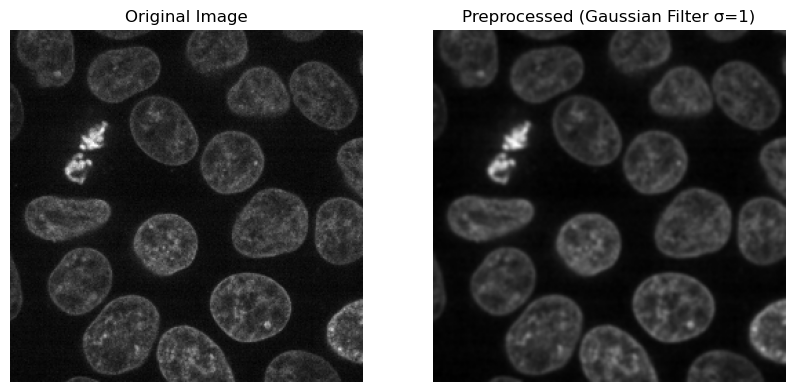

In [ ]:
# Load a simple image, as seen before
image = data.cells3d()[30, 1, :, :] # TODO: describe image loading, or insert actual image
# plt.title('Sample Cell Slice')
# plt.imshow(image, cmap='gray')

# Apply a Gaussian filter to the image
# Small sigma (1) for slight blurring, large sigma (4) for heavy blurring
sigma = 1
denoised_image_small = filters.gaussian(image, sigma=sigma)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Display original and denoised images
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(denoised_image_small, cmap='gray')
ax[1].set_title(f"Preprocessed (Gaussian Filter σ={sigma})")
ax[1].axis('off')

# TODO: get a slightly blurred image, and then smoothen it


## Thresholding


## Binary Images

## Masking


## Creating Objects (ROIs)

## Measurements

## Exercise